# MLIP Tutorial - Pooled Class Results (Part B: water)

One student sees a handful of models. The class between them varies **level of theory**,
**training-set size**, **architecture** and **fine-tuning** - enough to separate the levers,
which no individual run can do.

The metric here is **density error**, not force RMSE. Every submission also carries its
held-out force error, so the last section asks whether one predicts the other across the
whole class.

Expects the JSON files written by `export_water_results()`.

## Load the submissions

In [14]:
import json, glob, os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SRC  = '/content/drive/Shareddrives/AI4ChemicalSciences/Tutorials/MLIP/MACE_watermodel_jsons'
DEST = 'pooled_water'

try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        #drive.flush_and_unmount()
        drive.mount('/content/drive')
    os.chdir('/content')
    if os.path.isdir(SRC):
        os.makedirs(DEST, exist_ok=True)
        found = sorted(glob.glob(os.path.join(SRC, '**', '*.json'), recursive=True))
        for f in found:
            shutil.copy2(f, os.path.join(DEST, os.path.basename(f)))
        print(f'copied {len(found)} JSON files from the shared folder')
    else:
        print(f'{SRC} not found - falling back to whatever is already in {DEST}/')
except ImportError:
    print(f'not on Colab - reading {DEST}/ directly')

files = sorted(glob.glob(os.path.join(DEST, '*.json')))
if not files:
    raise FileNotFoundError(f'No JSON files in {DEST}/ - is the path right, and have '
                            f'the students uploaded yet?')

records, skipped = [], []
for f in files:
    try:
        r = json.load(open(f))
        # Part A exports land in the same folder; they have no density field.
        if 'density' in r:
            records.append(r)
    except Exception as e:                        # truncated or hand-edited file
        skipped.append((os.path.basename(f), str(e)))

if skipped:
    print(f'{len(skipped)} unreadable files:')
    for n, e in skipped:
        print(f'   {n}: {e}')

df = pd.DataFrame(records)

# a student who exported the same model twice keeps their latest
df = (df.sort_values('exported')
        .drop_duplicates(keep='last')
        .reset_index(drop=True))

df['train_min'] = df['train_time_s'] / 60
df['measure_s'] = df['measure_time_s']
df['abs_err']   = df['density_error_pct'].abs()
df['finetuned'] = df.get('foundation_model').notna() if 'foundation_model' in df else False


def hardware_label(row):
    gpu = row.get('gpu')
    if not isinstance(gpu, str) or not gpu:
        return 'unknown'
    g = gpu.replace('NVIDIA ', '').replace('-SXM4-40GB', '').replace('Tesla ', '')
    return g.strip()


df['hardware'] = df.apply(hardware_label, axis=1)

print(f'\n{len(df)} water submissions from {df["student"].nunique()} students')
print(f'  converged: {int(df["converged"].sum())}   '
      f'not converged: {int((~df["converged"]).sum())}')
print(f'  datasets used: {", ".join(sorted(df["dataset"].dropna().unique()))}')
print(f'  hardware: {", ".join(sorted(df["hardware"].unique()))}')

copied 10 JSON files from the shared folder

10 water submissions from 1 students
  converged: 2   not converged: 8
  datasets used: gfnff, revpbe0_d3, revpbe_d3, rpbe_d3
  hardware: A100, T4


## What did the class actually build?

In [15]:
print('submissions per dataset (level of theory):')
print(df.groupby('dataset').agg(n=('model', 'size'),
                                students=('student', 'nunique'),
                                median_err=('abs_err', 'median')).round(2).to_string())

print('\ntraining-set sizes used:')
print(df['n_train'].value_counts().sort_index().to_string())

print('\narchitectures:')
arch = df.groupby(['num_channels', 'max_L', 'r_max'], dropna=False).size()
print(arch.to_string())

print(f'\nfine-tuned submissions: {int(df["finetuned"].sum())} of {len(df)}')

submissions per dataset (level of theory):
            n  students  median_err
dataset                            
gfnff       2         1       40.58
revpbe0_d3  2         1       10.57
revpbe_d3   4         1        4.28
rpbe_d3     2         1       13.66

training-set sizes used:
n_train
50.0     2
100.0    2
250.0    2

architectures:
num_channels  max_L  r_max
32.0          0.0    5.0      4
NaN           NaN    NaN      6

fine-tuned submissions: 2 of 10


In [16]:
BASELINE_MODEL = 'water00'
base = df[df['model'] == BASELINE_MODEL]

if len(base):
    cal = (base.groupby('hardware')
               .agg(n=('train_min', 'size'),
                    train_min_median=('train_min', 'median'),
                    train_min_min=('train_min', 'min'),
                    train_min_max=('train_min', 'max'),
                    measure_s_median=('measure_s', 'median'))
               .sort_values('train_min_median'))
    print(f'Cost of the IDENTICAL {BASELINE_MODEL} model, by hardware:')
    print(cal.to_string(float_format=lambda v: f'{v:.2f}'))

    fastest = cal['train_min_median'].min()
    print('\nimplied hardware factor (relative to the fastest GPU in the room):')
    for hw, row in cal.iterrows():
        print(f'   {hw:<24s} {row["train_min_median"] / fastest:5.2f}x')

    spread = base.groupby('hardware')['train_min'].agg(
        lambda v: v.max() / v.min() if len(v) > 1 else np.nan)
    print('\nsame model, same hardware (max/min) - the noise floor on any cost claim:')
    print(spread.dropna().to_string(float_format=lambda v: f'{v:.2f}'))

    # The density itself should NOT depend on the machine. If it does, something is wrong.
    d = base[base['converged']]['density']
    if len(d) > 1:
        print(f'\n{BASELINE_MODEL} density across {len(d)} converged submissions: '
              f'{d.mean():.4f} +/- {d.std():.4f} g/cm3')
        print('  Same model and same protocol, so this spread is pure run-to-run noise.')
        print('  Any model difference smaller than it is not a real difference.')
else:
    print(f'No {BASELINE_MODEL!r} submissions - without the shared baseline there is no '
          f'way to calibrate machines, and no estimate of the noise floor.')

Cost of the IDENTICAL water00 model, by hardware:
          n  train_min_median  train_min_min  train_min_max  measure_s_median
hardware                                                                     
A100      1              1.45           1.45           1.45            176.86
T4        1              8.02           8.02           8.02            181.84

implied hardware factor (relative to the fastest GPU in the room):
   A100                      1.00x
   T4                        5.53x

same model, same hardware (max/min) - the noise floor on any cost claim:
Series([], )


## Pooled Pareto: density error against cost

Two cost axes. Training is paid once; measuring the density is paid every time you use the
model for anything. A model can win on one and lose on the other.

Colour is the **level of theory** it learned from - the lever no single student can vary
enough to see.

Non-converged submissions are excluded from the front (their density is not a
measurement) but plotted hollow, so you can see how many there were.

In [39]:
LOG_COST = True        # one very slow submission otherwise squashes everything

import plotly.graph_objects as go
from plotly.subplots import make_subplots

panels = [('train_min', 'training time (min)',        'One-off: cost to train'),
          ('measure_s', 'time to measure density (s)', 'Every use: cost to run')]

PALETTE = {'gfnff': '#e45756', 'revpbe_d3': '#4c78a8',
           'rpbe_d3': '#54a24b', 'revpbe0_d3': '#9d4edd'}


def pareto_front(cost, err):
    """Indices of non-dominated points, ordered by increasing cost."""
    idx, best = [], np.inf
    for i in np.argsort(cost):
        if err[i] < best:
            idx.append(i)
            best = err[i]
    return idx


def fmt(v, nd=0):
    """Fine-tuned models inherit their architecture - say so rather than 'nan'."""
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return 'inherited'
    return f'{v:.{nd}f}' if isinstance(v, float) else str(v)


def tooltip(r):
    return ('<b>{student} / {model}</b><br>'
            'trained on <b>{ds}</b>, {N} frames<br>'
            'max_L {L} &nbsp; channels {ch} &nbsp; r_max {rm}<br>'
            'fine-tuned: {ft} &nbsp; GPU: {hw}<br>'
            '<br>density <b>{rho}</b> g/cm3 &nbsp; error <b>{err}%</b><br>'
            'force RMSE {frm}% of |F|<br>'
            'train {tmin} min &nbsp; measure {ms} s<br>'
            '{conv}<br>'
            'max_epochs:{max_epochs}'
            ).format(student=r['student'], model=r['model'],
                     ds=r.get('dataset', '?'), N=fmt(r.get('n_train')),
                     L=fmt(r.get('max_L')), ch=fmt(r.get('num_channels')),
                     rm=fmt(r.get('r_max'), 1), ft='yes' if r['finetuned'] else 'no',
                     hw=r['hardware'],
                     rho=fmt(r.get('density'), 3), err=fmt(r.get('density_error_pct'), 1),
                     frm=fmt(r.get('F_rmse_pct'), 1),
                     tmin=fmt(r.get('train_min'), 1), ms=fmt(r.get('measure_s'), 0),
                     conv='' if r['converged'] else '<b>NOT CONVERGED</b>',
                     max_epochs=fmt(r.get('max_num_epochs')),
                     )


fig = make_subplots(rows=1, cols=2, shared_yaxes=True,
                    subplot_titles=[t for _, _, t in panels],
                    horizontal_spacing=0.06)

for col_i, (col, xlab, _) in enumerate(panels, start=1):
    d = df.dropna(subset=[col, 'abs_err']).reset_index(drop=True)
    ok = d[d['converged']].reset_index(drop=True)
    bad = d[~d['converged']].reset_index(drop=True)

    for ds, grp in ok.groupby('dataset'):
        fig.add_trace(go.Scatter(
            x=grp[col], y=grp['abs_err'], mode='markers', name=str(ds),
            legendgroup=str(ds), showlegend=(col_i == 1),
            marker=dict(size=11, color=PALETTE.get(ds, '#888'),
                        line=dict(width=1, color='black')),
            text=[tooltip(r) for _, r in grp.iterrows()],
            hovertemplate='%{text}<extra></extra>'), row=1, col=col_i)

    if len(bad):
        fig.add_trace(go.Scatter(
            x=bad[col], y=bad['abs_err'], mode='markers', name='not converged',
            legendgroup='bad', showlegend=(col_i == 1),
            marker=dict(size=10, color='rgba(0,0,0,0)',
                        line=dict(width=1.5, color='crimson')),
            text=[tooltip(r) for _, r in bad.iterrows()],
            hovertemplate='%{text}<extra></extra>'), row=1, col=col_i)

    if len(d) >= 2:
        front = pareto_front(d[col].to_numpy(float), d['abs_err'].to_numpy(float))
        fig.add_trace(go.Scatter(
            x=d.loc[front, col], y=d.loc[front, 'abs_err'], mode='lines',
            name='Pareto front', legendgroup='front', showlegend=(col_i == 1),
            line=dict(dash='dash', color='grey'), hoverinfo='skip'), row=1, col=col_i)

    fig.update_xaxes(title_text=xlab, type='log' if LOG_COST else 'linear',
                     row=1, col=col_i)

fig.update_yaxes(title_text='|density error| (%)', row=1, col=1)
fig.update_layout(height=520, width=1080, hovermode='closest',
                  title='Getting the density of water right, and what it cost',
                  legend=dict(title='trained on', orientation='h', y=-0.18))
fig.show()

## Which lever actually mattered?


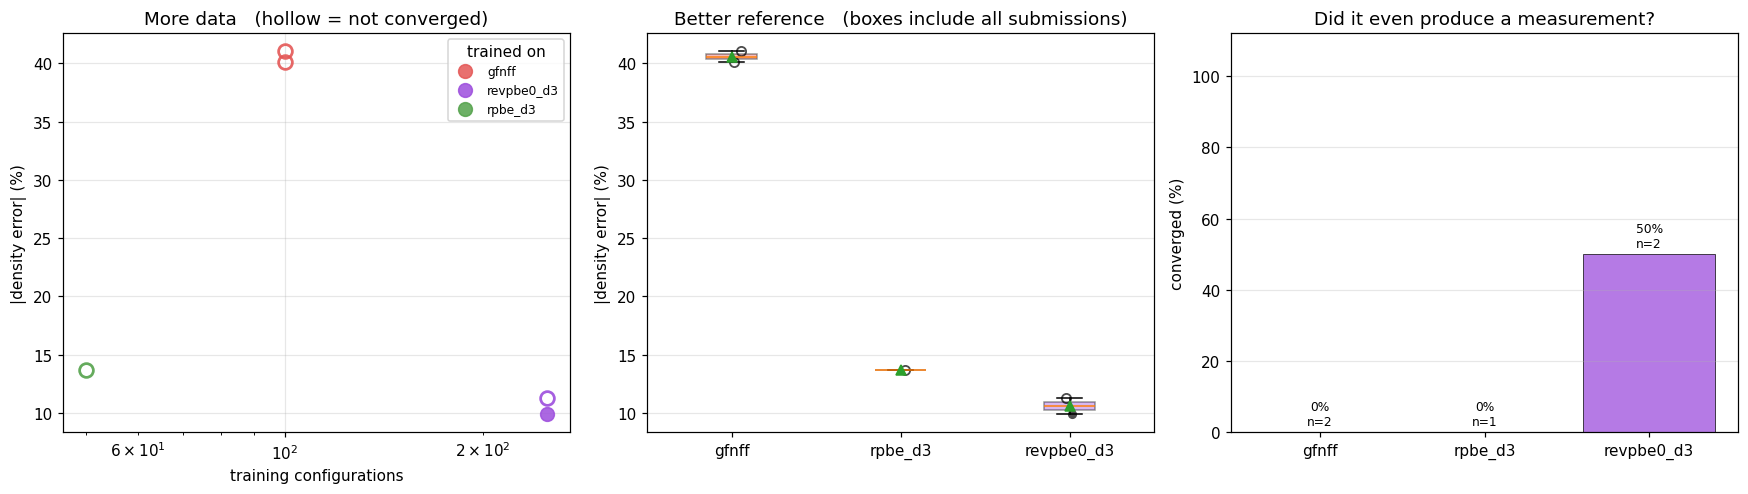

by level of theory:
            n  converged  median_all  median_converged  best
dataset                                                     
gfnff       2          0       40.58               NaN   NaN
revpbe0_d3  2          1       10.57              9.88  9.88
rpbe_d3     1          0       13.66               NaN   NaN

by training-set size:
         n  converged  median_all  median_converged
n_train                                            
50.0     1          0       13.66               NaN
100.0    2          0       40.58               NaN
250.0    2          1       10.57              9.88

fine-tuned vs from scratch:
           n  converged  median_converged
finetuned                                
False      3          0               NaN
True       2          1              9.88


In [21]:
# Every submission, converged or not. A run that could not hold a liquid box together is
# a result about that model, and dropping it flatters whichever dataset or size produced
# it. The density VALUES from those runs are not measurements, though, so they are drawn
# hollow and the trend lines are fitted to converged points only.
d = df.dropna(subset=['n_train', 'abs_err'])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), dpi=110)

for ds, grp in d.groupby('dataset'):
    c = PALETTE.get(ds, '#888')
    good, bad = grp[grp['converged']], grp[~grp['converged']]
    ax[0].plot(good['n_train'], good['abs_err'], 'o', markersize=9, color=c,
               alpha=0.85, label=str(ds))
    ax[0].plot(bad['n_train'], bad['abs_err'], 'o', markersize=9, markerfacecolor='none',
               markeredgecolor=c, markeredgewidth=1.8, alpha=0.9)
    med = good.groupby('n_train')['abs_err'].median()
    if len(med) > 1:
        ax[0].plot(med.index, med.values, '-', color=c, alpha=0.6)
ax[0].set_xlabel('training configurations'); ax[0].set_ylabel('|density error| (%)')
ax[0].set_xscale('log'); ax[0].set_title('More data   (hollow = not converged)')
ax[0].grid(alpha=0.3); ax[0].legend(title='trained on', fontsize=8)

order = [k for k in ['gfnff', 'revpbe_d3', 'rpbe_d3', 'revpbe0_d3']
         if k in set(d['dataset'])]
if order:
    bp = ax[1].boxplot([d[d['dataset'] == k]['abs_err'].to_numpy() for k in order],
                       tick_labels=order, showmeans=True, patch_artist=True)
    for patch, k in zip(bp['boxes'], order):
        patch.set_facecolor(PALETTE.get(k, '#888')); patch.set_alpha(0.4)
    rng = np.random.RandomState(0)
    for j, k in enumerate(order, start=1):
        g = d[d['dataset'] == k]
        for sub, hollow in [(g[g['converged']], False), (g[~g['converged']], True)]:
            if not len(sub):
                continue
            x = j + rng.uniform(-0.13, 0.13, len(sub))
            ax[1].plot(x, sub['abs_err'], 'o', markersize=6,
                       markerfacecolor='none' if hollow else 'black',
                       markeredgecolor='black', markeredgewidth=1.2 if hollow else 0,
                       alpha=0.7)
ax[1].set_ylabel('|density error| (%)')
ax[1].set_title('Better reference   (boxes include all submissions)')
ax[1].grid(alpha=0.3, axis='y')

if order:
    rate = d.groupby('dataset')['converged'].agg(['mean', 'size']).reindex(order)
    ax[2].bar(range(len(order)), 100 * rate['mean'],
              color=[PALETTE.get(k, '#888') for k in order], alpha=0.75,
              edgecolor='black', linewidth=0.6)
    ax[2].set_xticks(range(len(order))); ax[2].set_xticklabels(order)
    ax[2].set_ylim(0, 112); ax[2].set_ylabel('converged (%)')
    ax[2].set_title('Did it even produce a measurement?')
    for j, (m, n) in enumerate(zip(rate['mean'], rate['size'])):
        ax[2].text(j, 100 * m + 2, f'{int(round(100*m))}%\nn={int(n)}',
                   ha='center', fontsize=8)
    ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

ok = d[d['converged']]
summary = pd.DataFrame({
    'n':                d.groupby('dataset').size(),
    'converged':        d.groupby('dataset')['converged'].sum().astype(int),
    'median_all':       d.groupby('dataset')['abs_err'].median(),
    'median_converged': ok.groupby('dataset')['abs_err'].median(),
    'best':             ok.groupby('dataset')['abs_err'].min(),
}).round(2)
print('by level of theory:'); print(summary.to_string())

by_size = pd.DataFrame({
    'n':                d.groupby('n_train').size(),
    'converged':        d.groupby('n_train')['converged'].sum().astype(int),
    'median_all':       d.groupby('n_train')['abs_err'].median(),
    'median_converged': ok.groupby('n_train')['abs_err'].median(),
}).round(2)
print('\nby training-set size:'); print(by_size.to_string())

ft = pd.DataFrame({
    'n':                d.groupby('finetuned').size(),
    'converged':        d.groupby('finetuned')['converged'].sum().astype(int),
    'median_converged': ok.groupby('finetuned')['abs_err'].median(),
}).round(2)
print('\nfine-tuned vs from scratch:'); print(ft.to_string())

gap = (summary['median_all'] - summary['median_converged']).abs().max()
if gap > 1.0:
    print(f'\nmedian_all and median_converged differ by up to {gap:.1f} points. The failed '
          f'runs are\nnot measurements, so quote median_converged - but a low convergence '
          f'rate is itself a\nfinding about that choice.')

## Does the test set predict the density?

Part B asks each student this with three or four points. The class has enough to answer it.

Each model's force error is measured against **its own** reference, so the x-axis is
comparable across levels of theory even though the absolute energies are not.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning:

Degrees of freedom <= 0 for slice

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipykernel_475/1753781689.py:23: RankWarning:

Polyfit may be poorly conditioned



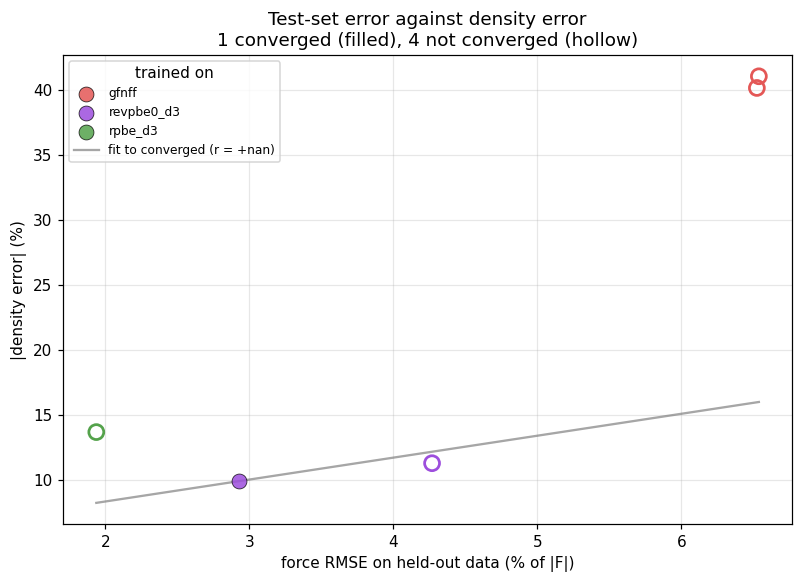

In [22]:
# Every submission, converged or not. The failed runs are the most interesting points on
# this plot: a model can post a respectable force error and still not hold a liquid box
# together, which is the strongest possible version of "the test set did not tell you".
d = df.dropna(subset=['F_rmse_pct', 'abs_err'])
ok, bad = d[d['converged']], d[~d['converged']]

if (len(ok) + len(bad)) < 3:
    print(f'only {len(ok)} converged submissions have both numbers - too few to say '
          f'anything about correlation')
else:
    plt.figure(figsize=(7.4, 5.4), dpi=110)
    for ds, grp in d.groupby('dataset'):
        c = PALETTE.get(ds, '#888')
        g, b = grp[grp['converged']], grp[~grp['converged']]
        plt.scatter(g['F_rmse_pct'], g['abs_err'], s=95, alpha=0.85, color=c,
                    edgecolor='k', linewidth=0.5, label=str(ds), zorder=3)
        plt.scatter(b['F_rmse_pct'], b['abs_err'], s=95, facecolor='none',
                    edgecolor=c, linewidth=1.8, zorder=3)

    # Fitted on converged points only: the density of a run that never settled is not a
    # measurement, so it cannot constrain a trend.
    r_ok = np.corrcoef(ok['F_rmse_pct'], ok['abs_err'])[0, 1]
    p = np.polyfit(ok['F_rmse_pct'], ok['abs_err'], 1)
    xs = np.linspace(d['F_rmse_pct'].min(), d['F_rmse_pct'].max(), 50)
    plt.plot(xs, np.polyval(p, xs), '-', color='grey', alpha=0.7,
             label=f'fit to converged (r = {r_ok:+.2f})')

    plt.xlabel('force RMSE on held-out data (% of |F|)')
    plt.ylabel('|density error| (%)')
    plt.title(f'Test-set error against density error\n'
              f'{len(ok)} converged (filled), {len(bad)} not converged (hollow)')
    plt.grid(alpha=0.3); plt.legend(title='trained on', fontsize=8)
    plt.tight_layout();

## Prompts for the discussion

1. **Where is the front?** Which submissions are on it, and is there a cheap model close
   to the best expensive one? That gap is the practical question in every MLIP paper.

2. **Data or theory?** Compare the vertical separation between colours against the slope
   within a colour. Which lever bought more accuracy per unit of effort?

3. **Did fine-tuning win?** It should on small datasets. If it did not, look at whether
   those submissions used enough epochs, or whether `E0s` was set appropriately.

4. **The noise floor.** The `water00` spread from the calibration cell is the smallest
   difference anyone can legitimately claim. How many of the differences being discussed
   are larger than it?

5. **Does the test set predict the verdict?** If the correlation is weak, that is the
   central claim of Part B, established with class-scale evidence rather than three points.

6. **The non-converged submissions.** How many, and did they cluster on particular
   datasets, temperatures or architectures? A model that cannot hold a liquid box together
   is telling you something, and it is not about its RMSE.